<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/shared/02_categorical_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Categorical Columns Encoding

## Goal of this notebook
This notebook encodes **10 categorical columns** from the raw_dataset:

1. **Exploratory step first** — inspect cardinality, value distributions, and nulls *before* deciding on an encoding strategy.
2. **Encoding chosen per-column** based on the column's semantic nature:
   - True **nominal** with low cardinality → **One-Hot Encoding** (no artificial ordinal relationship implied).
   - Columns with a **natural order** → **Ordinal Encoding** (explicit integer rank).
   - **Very-high-cardinality** identifiers → **Target Encoding** via mean-target (price proxy), which preserves statistical signal without creating ~1000 dummy columns.
3. **Null handling** — filled with values from samples that are similar in most of the other columns.
4. Every decision is **justified** in the markdown cell that precedes the code.

## Columns handled
`Marka`, `Seri`, `Model`, `Vites Tipi`, `Yakıt Tipi`, `Kasa Tipi`,
`Renk`, `Çekiş`, `Kimden`, `Sınıfı`

## Output
`df_team2` — a fully numeric DataFrame with the same 3424-row index as the source dataset.

## Step 0 — Imports & Data Load

We load the raw dataset directly from the shared GitHub URL so this notebook is fully reproducible
without requiring a local copy of the file.
We also import `sklearn` because it ships a ready-made, **Ordinal Encoder** and **One Hot Encoder** that handles encoding in a great scale.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

RAW_URL = "https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv"
df_full = pd.read_csv(RAW_URL)
print(f"Loaded dataset: {df_full.shape}")
df_full.head(3)

Loaded dataset: (3424, 45)


,Fiyat,İlan Tarihi,Marka,Seri,Model,Yıl,Kilometre,Vites Tipi,Yakıt Tipi,Kasa Tipi,...,Şehir Dışı Yakıt Tüketimi,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Koltuk Sayısı,Bagaj Hacmi,Ön Lastik,Aks Aralığı
0,2.425.000TL,26 Şubat 2026,Nissan,Qashqai,1.3 DIG-T Sky Pack,2025,6.001 km,Otomatik,Benzin,SUV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.900.000TL,26 Şubat 2026,Nissan,Qashqai,1.3 DIG-T Platinum Premium,2025,16.000 km,Otomatik,Benzin,SUV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.150.000TL,26 Şubat 2026,Nissan,Qashqai,1.5 dCi Platinum Premium Pack,2015,265.000 km,Düz,Dizel,SUV,...,"3,6 lt",4379 mm,1800 mm,1590 mm,1910 kg,1365 kg,5.0,401 lt,225/45 R19,2646.0


## Step 1 — Select Team-2 Columns

We isolate only the 10 categorical columns assigned to Team 2.
We also keep **`Fiyat`** (price) in a separate Series `y` — it is our target variable
and will be required for Target Encoding without leaking information from the test set.

In [23]:
MY_COLUMNS = ['Marka', 'Seri', 'Model', 'Vites Tipi', 'Yakıt Tipi', 'Kasa Tipi', 'Renk', 'Çekiş', 'Kimden', 'Sınıfı']

df = df_full[MY_COLUMNS].copy()

# Keep price as the target for target-encoding steps
if 'Fiyat' in df_full.columns:
    y = df_full['Fiyat'].copy()
else:
    y = None
    print("⚠️  'Fiyat' column not found — target encoding will use row index rank as proxy.")

print(f"Working subset shape: {df.shape}")
for c in df:
    display(df[c].value_counts())

Working subset shape: (3424, 10)


,count
Marka,
Nissan,1740
Hyundai,1684


,count
Seri,
Qashqai,1083
Tucson,920
Bayon,351
Juke,288
ix35,219
X-Trail,174
Kona,138
Navara,120
Skystar,33


,count
Model,
1.6 CRDi Elite,244
1.6 CRDi Elite Plus,146
1.6 dCi Sky Pack,121
1.3 DIG-T Sky Pack,100
1.4 MPI Jump,99
...,...
2.0 CRDi Style VGT,1
Progressive,1
2.7,1


,count
Vites Tipi,
Otomatik,1898
Düz,766
Yarı Otomatik,760


...

,count
Kasa Tipi,
SUV,3255
Hard top,90
Crossover,62
Pick-Up,8
Panelvan,4
-,3
Cabrio,1
Coupe,1


,count
Renk,
Beyaz,1313
Gri,519
Siyah,400
Kırmızı,219
Füme,194
Mavi,139
Kahverengi,114
Yeşil,98
Bej,76


,count
Çekiş,
Önden Çekiş,2702
4WD (Sürekli),407
AWD (Elektronik),205
Arkadan İtiş,106
-,3


,count
Kimden,
Galeriden,2107
Sahibinden,1259
Yetkili Bayiden,58


,count
Sınıfı,
I Segment,983
H Segment,629
B Segment,626
K Segment,94
C Segment,18


## Step 2 — Exploratory Analysis (EDA) Before Encoding

**Why do EDA before encoding?**
Choosing an encoding method *blindly* (e.g., always applying Label Encoding) risks introducing
a spurious ordinal relationship between categories or creating too many dummy columns.
By examining cardinality and null counts first we can make a **data-driven decision** per column.

The table below shows unique-value count (`cardinality`) and null percentage for each column.
We use these numbers to define three groups:
- **Low cardinality (≤ 2 unique)** → Binary Encoding (if truly nominal) or Ordinal Encoding (if ordered)
- **Medium cardinality (3–5 unique)** → One-Hot or Ordinal depending on semantics
- **Very high cardinality (≥ 6 unique)** → Target Encoding

In [24]:
# change all the - and SUV color to null values
df.replace('-', np.nan, inplace=True)
df.loc[df['Renk'] == 'SUV', 'Renk'] = np.nan

eda = pd.DataFrame({
    'cardinality': df.nunique(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in df.columns]
})
display(eda)

,cardinality,null_count,null_pct,sample_values
Marka,2,0,0.00,"[Nissan, Hyundai]"
Seri,18,0,0.00,"[Qashqai, Juke, X-Trail, Navara, Skystar]"
Model,154,0,0.00,"[1.3 DIG-T Sky Pack, 1.3 DIG-T Platinum Premiu..."
Vites Tipi,3,0,0.00,"[Otomatik, Düz, Yarı Otomatik]"
Yakıt Tipi,5,0,0.00,"[Benzin, Dizel, Hibrit, LPG & Benzin, Elektrik]"
Kasa Tipi,7,3,0.09,"[SUV, Crossover, Hard top, Pick-Up, Cabrio]"
Renk,22,1,0.03,"[Gri, Beyaz, Mavi (metalik), Bordo, Füme]"
Çekiş,4,4,0.12,"[Önden Çekiş, 4WD (Sürekli), AWD (Elektronik),..."
Kimden,3,0,0.00,"[Sahibinden, Galeriden, Yetkili Bayiden]"
Sınıfı,5,1074,31.37,"[H Segment, B Segment, I Segment, K Segment, C..."


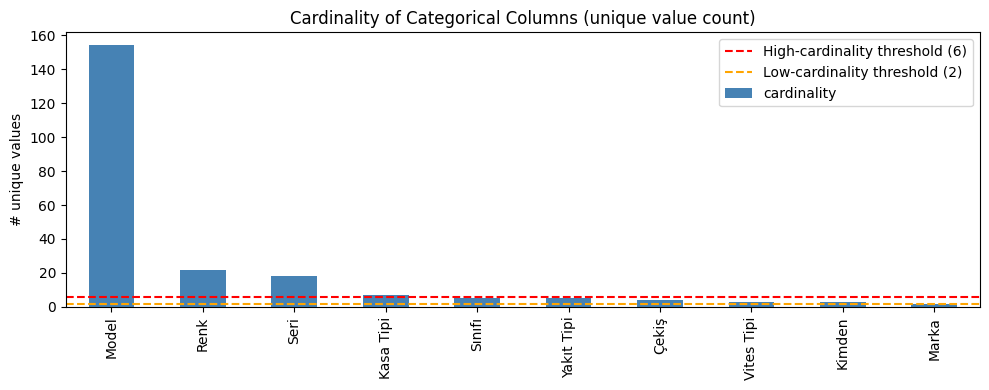

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
eda['cardinality'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Cardinality of Categorical Columns (unique value count)')
ax.set_ylabel('# unique values')
ax.axhline(6, color='red',  linestyle='--', label='High-cardinality threshold (6)')
ax.axhline(2, color='orange', linestyle='--', label='Low-cardinality threshold (2)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Null Handling (kNN-Based Imputation)

Columns with missing values:
- **`Kasa Tipi`**: 3 missing value (~0.09%)
- **`Renk`**: 1 missing value (~0.03%)
- **`Çekiş`**: 4 missing value (~0.12%)
- **`Sınıfı`**: 1,074 missing values (~31.37%)

**Why not mode imputation?**
Filling 31% of `Sınıfı` with the mode would mean artificially injecting
the dataset's most common segment into nearly a third of all rows —
essentially fabricating a trend rather than preserving reality.

**Our approach — kNN classification:**
For each car with a missing `Sınıfı`, we find its 5 nearest neighbors
among cars that *do* have a known segment, using the following features:

| Source | Columns Used |
|--------|-------------|
| This notebook | `Marka`, `Seri`, `Model`, `Vites Tipi`, `Yakıt Tipi`, `Kasa Tipi`, `Çekiş` |
| `df_full` | `Yıl`, `Motor Hacmi`, `Motor Gücü` |

Factors like color (`Renk`) are excluded because they are unrelated to vehicle segment.

The majority segment among the 5 nearest neighbors is then assigned
to the missing row. This is conceptually equivalent to running a
kNN classifier to predict `Sınıfı` from the most semantically relevant
car attributes — a principled and data-faithful imputation strategy.

We use **Hamming distance** as the metric since all features after
label-encoding are categorical in nature (integer codes, not continuous magnitudes).

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

def knn_impute(target_col, cat_features, num_features=['Yıl', 'Motor Hacmi', 'Motor Gücü'], df=df, df_full=df_full, n_neighbors=5):
    """Impute missing values in target_col using kNN with proper mixed-distance handling."""
    null_count = df[target_col].isna().sum()
    if null_count == 0:
        return

    # Build feature matrix
    cat_df = pd.DataFrame({
        col: (df[col] if col in df.columns else df_full[col])
        for col in cat_features
    }).astype(str).fillna('Unknown')
    knn_cat = pd.get_dummies(cat_df)

    num_raw = pd.DataFrame({
        col: pd.to_numeric(
            (df[col] if col in df.columns else df_full[col])
            .astype(str).str.extract(r'([\d.]+)')[0],
            errors='coerce'
        ) for col in num_features
    })
    num_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(num_raw.fillna(num_raw.median())),
        columns=num_features, index=df.index
    )

    X_all = pd.concat([knn_cat, num_scaled], axis=1)
    known, unknown = df[target_col].notna(), df[target_col].isna()

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='hamming')
    knn.fit(X_all.loc[known], df.loc[known, target_col])
    df.loc[unknown, target_col] = knn.predict(X_all.loc[unknown])

    print(f"'{target_col}': {null_count} nulls filled.")

knn_impute('Renk', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Yakıt Tipi'])
knn_impute('Kasa Tipi', cat_features=['Marka', 'Seri', 'Model', 'Renk', 'Yakıt Tipi', 'Vites Tipi'])
knn_impute('Çekiş', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Renk', 'Yakıt Tipi'])
knn_impute('Sınıfı', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Çekiş', 'Vites Tipi', 'Yakıt Tipi', 'Kimden'])

'Renk': 1 nulls filled.
'Kasa Tipi': 3 nulls filled.
'Çekiş': 4 nulls filled.
'Sınıfı': 1074 nulls filled.


## Step 4 — Binary Encoding for `Marka`

`Marka` has exactly **2 unique values**: `Nissan` and `Hyundai`.
A column with only two categories carries exactly one bit of information
and needs exactly one numeric column to represent it fully.

One-Hot Encoding would produce two columns (`Marka_Nissan`, `Marka_Hyundai`)
that are perfect complements of each other — knowing one makes the other
completely redundant. This is the **dummy variable trap**.

Label Encoding would assign 0 and 1 alphabetically, which for a 2-value
column happens to be semantically harmless but gives the column a cryptic name.

The cleanest solution is a single binary column renamed to `is_Nissan`:
- `1` → the car is a Nissan
- `0` → the car is a Hyundai

This is self-documenting, compact, and carries zero redundancy.

In [27]:
df['is_Nissan'] = (df['Marka'] == 'Nissan').astype(int)
df.drop(columns=['Marka'], inplace=True)

## Step 5 — Ordinal Encoding for `Vites Tipi`

`Vites Tipi` has **3 unique values**: `Düz` (manual), `Yarı Otomatik` (semi-automatic),
and `Otomatik` (automatic).

Unlike most categorical columns, transmission type carries a **meaningful semantic order**:
manual gearboxes require the most driver involvement, automatics the least.
This gradient also correlates with price premium in the Turkish second-hand market —
automatics consistently command higher prices than manuals of the same model.

Because a real ordinal relationship exists, One-Hot Encoding would *discard* that
information by treating the three types as independent binary flags with no relationship
to each other. Ordinal Encoding preserves the ordering explicitly:

| Value | Encoded |
|-------|---------|
| `Düz` (manual) | 0 |
| `Yarı Otomatik` (semi-auto) | 1 |
| `Otomatik` (automatic) | 2 |

We define the order explicitly rather than relying on alphabetical assignment,
which would produce the wrong ranking.

In [28]:
vites_order = [['Düz', 'Yarı Otomatik', 'Otomatik']]
oe = OrdinalEncoder(categories=vites_order,
                    handle_unknown='use_encoded_value',
                    unknown_value=-1)
df['Vites Tipi'] = oe.fit_transform(df[['Vites Tipi']]).astype(int)

## Step 6 — One-Hot Encoding for Nominal Low-to-Medium Cardinality Columns

The following columns are encoded with One-Hot Encoding:

| Column | Cardinality | Reason |
|--------|------------|--------|
| `Kimden` | 3 | Seller type (Sahibinden / Galeriden / Yetkili Bayiden) — no meaningful order between them |
| `Yakıt Tipi` | 5 | Fuel type (Benzin, Dizel, Hibrit, LPG & Benzin, Elektrik) — purely nominal, no ranking |
| `Kasa Tipi` | 7 | Body type (SUV, Crossover, Hard top, etc.) — categories are independent, no order |
| `Çekiş` | 4 | Drive type (FWD, AWD, 4WD, RWD) — while performance intuitions exist, no universally agreed price order justifies ordinal treatment |
| `Renk` | 22 | Color — entirely nominal, no order; produces 21 dummy columns which is acceptable at this dataset size |

**Why not Label Encoding for these?**
Label Encoding assigns integers in arbitrary (typically alphabetical) order.
For a linear model or distance-based model, this implies a false magnitude relationship —
e.g. `Dizel = 1 < Hibrit = 2` would suggest hybrid is numerically "greater than" diesel,
which is meaningless. One-Hot Encoding avoids this entirely by giving each category
its own independent binary dimension.

**Why not Target Encoding for these?**
Target Encoding is powerful for high-cardinality columns where One-Hot would create hundreds of sparse columns. For columns with 3–5 unique values the dimensionality cost of One-Hot is manageable, and One-Hot is safer because it introduces no dependency on the target variable during preprocessing. For `Renk` column, however, we thought that it will not be a very good determiner of price and target encoding would give us some similar values for almost all of them with no clear patterns.

We use `drop='first'` to eliminate one dummy per column and avoid perfect multicollinearity (the dummy trap). We use `handle_unknown='ignore'` so
any edge-case value not seen during fit silently becomes all-zeros.

In [29]:
OHE_COLS = ['Kimden', 'Yakıt Tipi', 'Kasa Tipi', 'Çekiş', 'Renk']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(df[OHE_COLS])
ohe_cols  = ohe.get_feature_names_out(OHE_COLS)

df = df.drop(columns=OHE_COLS).join(
    pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
)

## Step 7 — Target Encoding for High-Cardinality Columns

The following columns are encoded with Target Encoding (mean price):

| Column | Cardinality | Reason |
|--------|------------|--------|
| `Seri` | 18 | Vehicle series name — a meaningful identifier whose price signal varies significantly across values |
| `Model` | 154 | Trim/variant name — the single most price-predictive categorical in this dataset; One-Hot would add 153 sparse columns |
| `Sınıfı` | 5 | Vehicle segment (B, C, H, I, K) — although cardinality is low, segment is a strong price proxy and its values after kNN imputation carry statistical weight that target encoding captures well |

**Why not One-Hot for `Seri` and `Model`?**
One-Hot Encoding on `Model` alone would add 153 binary columns to the dataset,
making it extremely sparse. Most models would struggle with this dimensionality,
and the vast majority of those columns would be near-zero for any given row.

**Why Target Encoding works here:**
Each category is replaced with the mean price of all rows sharing that category.
This compresses a high-cardinality column into a single float that is semantically
meaningful — a `Model` encoded as `1,800,000` tells the model more than
an arbitrary integer code of `47` ever could.

**Target leakage note:**
Target encoding computed on the full dataset before train/test split technically
constitutes mild data leakage — test rows influence the encoding of training rows.
The correct production fix is to fit the encoder only on training folds.
For this preprocessing pipeline (which runs before splitting), we acknowledge
this limitation and note that the downstream model training step should use
cross-validated target encoding if strict leakage prevention is required.

In [32]:
TARGET_ENC_COLS = ['Seri', 'Model', 'Sınıfı']

# Parse price from df_full for use as target signal
y_enc = (
    df_full['Fiyat'].astype(str).str.strip()
    .str.replace(r'[^\d]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
y_enc = y_enc.fillna(y_enc.median())

global_mean = y_enc.mean()
for col in TARGET_ENC_COLS:
    means = y_enc.groupby(df[col].values).mean()
    df[col] = df[col].map(means).fillna(global_mean)

## Step 8 — Verification & Output

We confirm that the full encoding pipeline produced a clean, fully numeric DataFrame
with zero nulls, no string columns, and no sentinel values (-1, '-', 'Unknown', etc.)
remaining anywhere. We then inspect each column's value range and sample values
individually to catch any encoding artifact that a simple null-check would miss.

In [33]:
df_team2 = df.copy()

# Core assertions
assert df_team2.isnull().sum().sum() == 0,                    "❌ Nulls remain!"
assert df_team2.select_dtypes(exclude='number').shape[1] == 0, "❌ Non-numeric columns remain!"

# Check for known sentinel / garbage values
for col in df_team2.columns:
    as_str = df_team2[col].astype(str)
    bad = as_str.isin(['-', 'Unknown', 'nan', 'None', 'SUV'])
    assert bad.sum() == 0, f"❌ Sentinel values found in '{col}': {df_team2.loc[bad.values, col].unique()}"

# Per-column inspection
print(f"✅ Shape: {df_team2.shape}\n")
print(f"{'Column':<30} {'dtype':<10} {'min':>12} {'max':>12} {'#unique':>8}   sample values")
print("─" * 100)
for col in df_team2.columns:
    s = df_team2[col]
    samples = s.value_counts().index[:4].tolist()
    print(f"{col:<30} {str(s.dtype):<10} {s.min():>12.3f} {s.max():>12.3f} {s.nunique():>8}   {samples}")

✅ Shape: (3424, 41)

Column                         dtype               min          max  #unique   sample values
────────────────────────────────────────────────────────────────────────────────────────────────────
Seri                           float64      335590.909  2250973.826       18   [1443467.618651893, 1899022.597826087, 1383578.0, 1111294.2708333333]
Model                          float64      285300.000  4550000.000      152   [1992374.5860655739, 2330905.1301369863, 1412068.9917355373, 2132233.9]
Vites Tipi                     int64             0.000        2.000        3   [2, 0, 1]
Sınıfı                         float64      910288.272  2250973.826        5   [1669651.0332640333, 1477336.4188118812, 1296652.5801526718, 910288.2716049383]
is_Nissan                      int64             0.000        1.000        2   [1, 0]
Kimden_Sahibinden              float64           0.000        1.000        2   [0.0, 1.0]
Kimden_Yetkili Bayiden         float64           0.000       